In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

In [2]:
# Ouverture du fichier d'origine avec des ; comme séparateur et affichage des premières lignes
df=pd.read_csv('eco2mix-regional-cons-def.csv', sep = ';')

display(df.head())

C:\Users\pauls\AppData\Local\Temp\ipykernel_14836\4110533192.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('eco2mix-regional-cons-def.csv', sep = ';')


,Code INSEE région,Région,Nature,Date,Heure,Date - Heure,Consommation (MW),Thermique (MW),Nucléaire (MW),Eolien (MW),...,TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Column 30
0,27,Bourgogne-Franche-Comté,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,76,Occitanie,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,44,Grand Est,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28,Normandie,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,84,Auvergne-Rhône-Alpes,Données définitives,2013-01-01,00:00,2013-01-01T00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Visualisation du nombre de colonnes et de lignes et du type des valeurs de chaque variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121408 entries, 0 to 2121407
Data columns (total 32 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Code INSEE région    int64  
 1   Région               object 
 2   Nature               object 
 3   Date                 object 
 4   Heure                object 
 5   Date - Heure         object 
 6   Consommation (MW)    float64
 7   Thermique (MW)       float64
 8   Nucléaire (MW)       float64
 9   Eolien (MW)          object 
 10  Solaire (MW)         float64
 11  Hydraulique (MW)     float64
 12  Pompage (MW)         float64
 13  Bioénergies (MW)     float64
 14  Ech. physiques (MW)  float64
 15  Stockage batterie    float64
 16  Déstockage batterie  float64
 17  Eolien terrestre     float64
 18  Eolien offshore      float64
 19  TCO Thermique (%)    float64
 20  TCH Thermique (%)    float64
 21  TCO Nucléaire (%)    float64
 22  TCH Nucléaire (%)    float64
 23  TCO Eolien (%)       float64
 24

In [4]:
# Modification du type de la colonne 'Eolien (MW)' suite au message d'erreur "Columns (9) have mixed types."
# à l'ouverture du fichier
# Première étape : remplacement des différentes valeurs 'ND' et '-' par des NAN, pour pouvoir changer de type
df['Eolien (MW)'] = df['Eolien (MW)'].replace(['ND', '-'], np.nan)
df['Eolien (MW)'] = df['Eolien (MW)'].astype(float)

In [5]:
# Modification des colonnes date en type datetime
# La colonne 'Date' est à l'heure locale de la France, alors que la colonne 'Date - Heure' est à l'heure UTC, nous
# préférons garder ces 2 colonnes
df['Date'] = pd.to_datetime(df['Date'])
df['Date - Heure'] = pd.to_datetime(df['Date - Heure'])

C:\Users\pauls\AppData\Local\Temp\ipykernel_14836\46727564.py:5: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date - Heure'] = pd.to_datetime(df['Date - Heure'])


In [6]:
# Ajout d'une colonne 'Year' juste après la colone Heure, pour faciliter le maniement des données par la suite,
# notamment la construction des premiers graphiques
df['Year'] = df['Date'].dt.year
year = df.pop('Year')
df.insert(5, 'Year', year)
display(df.head())

,Code INSEE région,Région,Nature,Date,Heure,Year,Date - Heure,Consommation (MW),Thermique (MW),Nucléaire (MW),...,TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Column 30
0,27,Bourgogne-Franche-Comté,Données définitives,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,76,Occitanie,Données définitives,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,44,Grand Est,Données définitives,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28,Normandie,Données définitives,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,84,Auvergne-Rhône-Alpes,Données définitives,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Vérification qu'il n'y a pas de doublons : c'est le cas
df.duplicated().sum()

0

In [8]:
# Pour 2023, seules les données du mois de janvier sont présentes et sont de type consolidées
# Les dernières données datent du 31 janvier 2023 à 23:30
display(df.tail())


,Code INSEE région,Région,Nature,Date,Heure,Year,Date - Heure,Consommation (MW),Thermique (MW),Nucléaire (MW),...,TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Column 30
2121403,53,Bretagne,Données consolidées,2023-01-31,23:30,2023,2023-01-31 23:30:00+01:00,3266.0,683.0,0.0,...,NaN,4.16,10.42,0.0,0.0,0.34,4.00,1.68,75.34,NaN
2121404,27,Bourgogne-Franche-Comté,Données consolidées,2023-01-31,23:30,2023,2023-01-31 23:30:00+01:00,2687.0,166.0,0.0,...,NaN,7.82,20.45,0.0,0.0,8.19,42.07,1.82,61.25,NaN
2121405,84,Auvergne-Rhône-Alpes,Données consolidées,2023-01-31,23:30,2023,2023-01-31 23:30:00+01:00,8927.0,390.0,13291.0,...,97.94,1.66,20.47,0.0,0.0,32.90,25.76,1.25,58.64,NaN
2121406,93,Provence-Alpes-Côte d'Azur,Données consolidées,2023-01-31,23:30,2023,2023-01-31 23:30:00+01:00,6139.0,350.0,0.0,...,NaN,0.72,45.83,0.0,0.0,30.14,56.68,1.40,28.96,NaN
2121407,52,Pays de la Loire,Données consolidées,2023-01-31,23:30,2023,2023-01-31 23:30:00+01:00,3826.0,172.0,0.0,...,NaN,5.36,11.88,0.0,0.0,0.16,60.00,1.52,70.73,NaN


In [9]:
# Nombre de données par année
nb_data_year = df.groupby('Year').size()
print(nb_data_year)
# Les 17856 lignes de 2023 correspondent au mois de janvier

Year
2013    210240
2014    210240
2015    210240
2016    210816
2017    210240
2018    210240
2019    210240
2020    210816
2021    210240
2022    210240
2023     17856
dtype: int64


In [10]:
# Visualisation de la nature des données groupées par année
data_nature = df.groupby('Year')['Nature'].unique()
print(data_nature)


Year
2013    [Données définitives]
2014    [Données définitives]
2015    [Données définitives]
2016    [Données définitives]
2017    [Données définitives]
2018    [Données définitives]
2019    [Données définitives]
2020    [Données définitives]
2021    [Données définitives]
2022    [Données définitives]
2023    [Données consolidées]
Name: Nature, dtype: object


In [11]:
# Étant donné que dans la suite de nos analyses, nous travaillerons par années, nous décidons de supprimer
# l'année 2023 (données sur 1 seul mois et données non validées(consolidées))
df = df[df['Year'] != 2023]


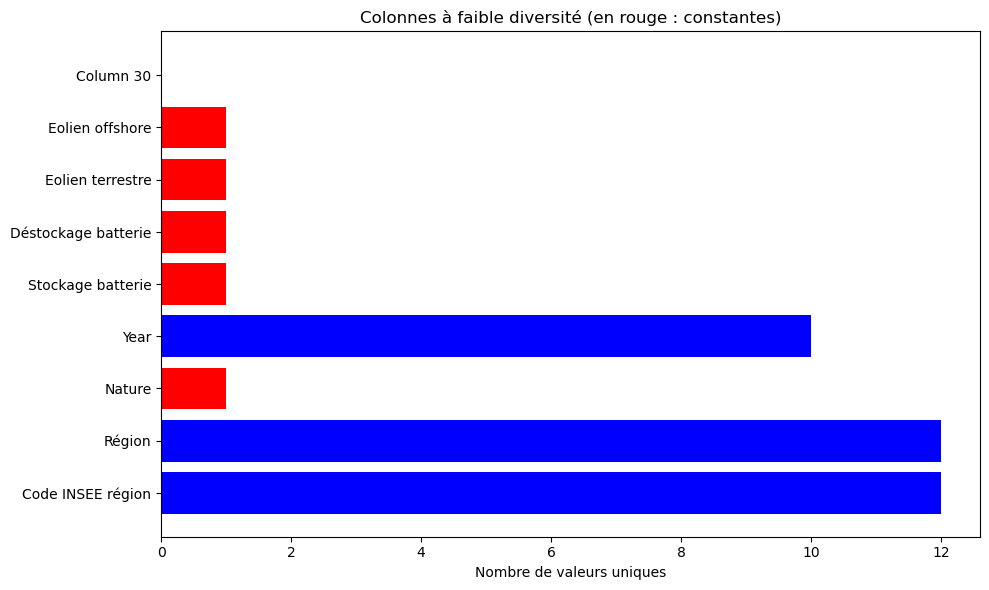

In [12]:
# Exploration des colonnes avec peu de valeurs uniques
n_unique = df.nunique()
filtered = n_unique[n_unique < 20]

# On filtre avec la couleur : rouge pour des constantes et bleu pour quasi-constantes
colors = ['red' if val == 1 else 'blue' for val in filtered]

plt.figure(figsize=(10, 6))
bars = plt.barh(filtered.index, filtered.values, color=colors)
plt.xlabel("Nombre de valeurs uniques")
plt.title("Colonnes à faible diversité (en rouge : constantes)")
plt.tight_layout()
plt.show()

# Il s'avère que les colonnes : 'Nature', Stockage batterie', 'Déstockage batterie', 'Eolien terrestre', 
# 'Eolien offshore', 'Column 30' ne contiennent qu'une valeur ou des valeurs NAN 


In [13]:
# Suppression de ces 6 colonnes
df = df.drop(['Nature', 'Stockage batterie', 'Déstockage batterie', 'Eolien terrestre', 'Eolien offshore', 'Column 30'], axis=1)


In [14]:
# Il existe un unique code INSEE par région
df.groupby('Région')['Code INSEE région'].unique()

Région
Auvergne-Rhône-Alpes          [84]
Bourgogne-Franche-Comté       [27]
Bretagne                      [53]
Centre-Val de Loire           [24]
Grand Est                     [44]
Hauts-de-France               [32]
Normandie                     [28]
Nouvelle-Aquitaine            [75]
Occitanie                     [76]
Pays de la Loire              [52]
Provence-Alpes-Côte d'Azur    [93]
Île-de-France                 [11]
Name: Code INSEE région, dtype: object

In [15]:
# Remplacement des codes INSEE par des abréviations plus parlantes & changement du nom de la colonne
# Cela nous servira pour certains graphiques par la suite
insee_map = {
    11 : 'IDF',
    24 : 'CVL',
    27 : 'BFC',
    28 : 'NOR',
    32 : 'HDF',
    44 : 'GES',
    52 : 'PDL',
    53 : 'BRE',
    75 : 'NAQ',
    76 : 'OCC',
    84 : 'ARA',
    93 : 'PAC'}
df['Code INSEE région'] = df['Code INSEE région'].replace(insee_map)
df = df.rename(columns={'Code INSEE région': 'Code région'})

In [16]:
# Nous décidons de simplifier le nom de certaines colonnes (suppression des (MW) et des (%))
df.columns = df.columns.str.replace(r'\s*\(MW\)|\s*\(%\)', '', regex=True)

In [17]:
# Vérifions que les variables sont toutes au bon type, que les colonnes ont bien été renommées et que les 6 
# colonnes supprimées ne sont plus présentes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2103552 entries, 0 to 2103551
Data columns (total 27 columns):
 #   Column           Dtype         
---  ------           -----         
 0   Code région      object        
 1   Région           object        
 2   Date             datetime64[ns]
 3   Heure            object        
 4   Year             int32         
 5   Date - Heure     object        
 6   Consommation     float64       
 7   Thermique        float64       
 8   Nucléaire        float64       
 9   Eolien           float64       
 10  Solaire          float64       
 11  Hydraulique      float64       
 12  Pompage          float64       
 13  Bioénergies      float64       
 14  Ech. physiques   float64       
 15  TCO Thermique    float64       
 16  TCH Thermique    float64       
 17  TCO Nucléaire    float64       
 18  TCH Nucléaire    float64       
 19  TCO Eolien       float64       
 20  TCH Eolien       float64       
 21  TCO Solaire      float64       
 22 

In [18]:
# Gestion des NAN, en regardant quelles variables sont concernées (nombres de valeurs NAN par colonne)
df.isna().sum()

Code région              0
Région                   0
Date                     0
Heure                    0
Year                     0
Date - Heure             0
Consommation            12
Thermique               12
Nucléaire           701287
Eolien                 108
Solaire                 12
Hydraulique             12
Pompage             736327
Bioénergies             12
Ech. physiques          12
TCO Thermique      1472256
TCH Thermique      1472256
TCO Nucléaire      1560096
TCH Nucléaire      1735296
TCO Eolien         1472256
TCH Eolien         1472256
TCO Solaire        1472256
TCH Solaire        1472256
TCO Hydraulique    1472256
TCH Hydraulique    1472256
TCO Bioénergies    1472256
TCH Bioénergies    1472256
dtype: int64

In [19]:
# Les 12 lignes où la Consommation est NAN, toutes les colonnes de mesures (variables numériques) sont également NAN
lignes = df[df['Consommation'].isna()]
display(lignes)

,Code région,Région,Date,Heure,Year,Date - Heure,Consommation,Thermique,Nucléaire,Eolien,...,TCO Nucléaire,TCH Nucléaire,TCO Eolien,TCH Eolien,TCO Solaire,TCH Solaire,TCO Hydraulique,TCH Hydraulique,TCO Bioénergies,TCH Bioénergies
0,BFC,Bourgogne-Franche-Comté,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OCC,Occitanie,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GES,Grand Est,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NOR,Normandie,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARA,Auvergne-Rhône-Alpes,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,PAC,Provence-Alpes-Côte d'Azur,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,BRE,Bretagne,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,IDF,Île-de-France,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,HDF,Hauts-de-France,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,PDL,Pays de la Loire,2013-01-01,00:00,2013,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Suppression de ces 12 lignes
df = df.dropna(subset = ['Consommation'])

In [21]:
# Les lignes où la production éolienne a pour valeur NAN correspondent à 2 journées entières dans 2 régions distinctes :
# Journée du 8 mai 2013 en Île-de-France (48 valeurs)
# Journée du 27 décembre 2013 en Centre-Val de Loire (48 valeurs)
lignes = df[df['Eolien'].isna()]
display(lignes)

,Code région,Région,Date,Heure,Year,Date - Heure,Consommation,Thermique,Nucléaire,Eolien,...,TCO Nucléaire,TCH Nucléaire,TCO Eolien,TCH Eolien,TCO Solaire,TCH Solaire,TCO Hydraulique,TCH Hydraulique,TCO Bioénergies,TCH Bioénergies
73175,IDF,Île-de-France,2013-05-08,00:30,2013,2013-05-08 00:30:00+02:00,6705.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73186,IDF,Île-de-France,2013-05-08,01:00,2013,2013-05-08 01:00:00+02:00,6270.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73199,IDF,Île-de-France,2013-05-08,01:30,2013,2013-05-08 01:30:00+02:00,5814.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73201,IDF,Île-de-France,2013-05-08,02:00,2013,2013-05-08 02:00:00+02:00,5591.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73212,IDF,Île-de-France,2013-05-08,02:30,2013,2013-05-08 02:30:00+02:00,5506.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207896,CVL,Centre-Val de Loire,2013-12-27,22:00,2013,2013-12-27 22:00:00+01:00,2388.0,77.0,9419.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207911,CVL,Centre-Val de Loire,2013-12-27,22:30,2013,2013-12-27 22:30:00+01:00,2353.0,77.0,9365.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207918,CVL,Centre-Val de Loire,2013-12-27,23:00,2013,2013-12-27 23:00:00+01:00,2383.0,77.0,9401.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207928,CVL,Centre-Val de Loire,2013-12-27,23:30,2013,2013-12-27 23:30:00+01:00,2303.0,77.0,9388.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


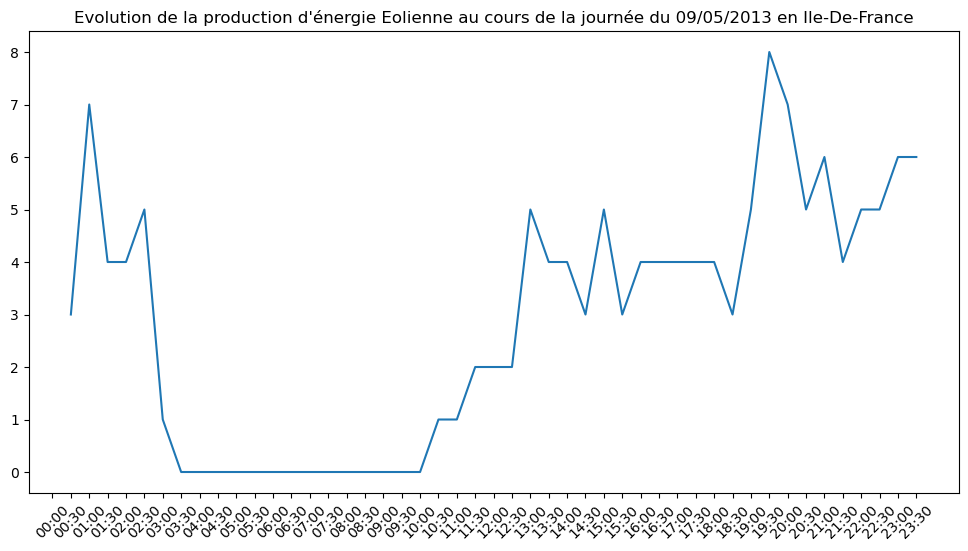

In [22]:
# Plutôt que de supprimer ces 96 lignes qui comportent de nombreuses autres mesures,
# nous décidons de remplacer les données manquantes par les données représentatives, soit le jour suivant.

# Journée NAN du 8 mai 2013 en Île-de-France
# Filtrer pour la région Île-de-France
idf = df[df["Région"] == "Île-de-France"]

# Les données du 9 mai 2013
idf = idf[(idf["Date"] == "2013-05-09")]

# Tracer la production éolienne
plt.figure(figsize=(12, 6))
plt.plot(idf["Heure"], idf["Eolien"], label = "Production éol")
plt.xticks(rotation = 45)
plt.title("Evolution de la production d'énergie Eolienne au cours de la journée du 09/05/2013 en Ile-De-France")
plt.show()

# On fait pareil pour la journée manquante du Centre val de Loire en remplaçant par la journée suivante.

In [23]:
# Sélection des lignes à remplacer
idf_8 = df[(df['Date'] == '2013-05-08') & (df['Heure'] != '00:00') & (df['Région'] == 'Île-de-France')]['Eolien']
idf_9 = df[(df['Date'] == '2013-05-09') & (df['Région'] == 'Île-de-France')]['Eolien']

# Remplacement des valeurs
df.loc[(df['Date'] == '2013-05-08') & (df['Région'] == 'Île-de-France'), 'Eolien'] = idf_9.values
# Il reste un NAN le 08/05/2013 à 00h00 et le 09/05/2013 à 00h00 du fait du décalage de fuseau horaire entre Europe/Paris et UTC. 
# On les remplace donc par les valeurs suivantes soit celles de 00h30 
df.loc[(df['Date'] == '2013-05-08') &(df['Région'] == 'Île-de-France') &(df['Heure'] == '00:00'),'Eolien'] = 3
df.loc[(df['Date'] == '2013-05-09') &(df['Région'] == 'Île-de-France') &(df['Heure'] == '00:00'),'Eolien'] = 6

df.loc[(df['Date'] == '2013-05-08') & (df['Région'] == 'Île-de-France')]

,Code région,Région,Date,Heure,Year,Date - Heure,Consommation,Thermique,Nucléaire,Eolien,...,TCO Nucléaire,TCH Nucléaire,TCO Eolien,TCH Eolien,TCO Solaire,TCH Solaire,TCO Hydraulique,TCH Hydraulique,TCO Bioénergies,TCH Bioénergies
73154,IDF,Île-de-France,2013-05-08,00:00,2013,2013-05-08 00:00:00+02:00,6981.0,1.0,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73175,IDF,Île-de-France,2013-05-08,00:30,2013,2013-05-08 00:30:00+02:00,6705.0,1.0,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73186,IDF,Île-de-France,2013-05-08,01:00,2013,2013-05-08 01:00:00+02:00,6270.0,1.0,NaN,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73199,IDF,Île-de-France,2013-05-08,01:30,2013,2013-05-08 01:30:00+02:00,5814.0,1.0,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73201,IDF,Île-de-France,2013-05-08,02:00,2013,2013-05-08 02:00:00+02:00,5591.0,1.0,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73212,IDF,Île-de-France,2013-05-08,02:30,2013,2013-05-08 02:30:00+02:00,5506.0,1.0,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73229,IDF,Île-de-France,2013-05-08,03:00,2013,2013-05-08 03:00:00+02:00,5285.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73247,IDF,Île-de-France,2013-05-08,03:30,2013,2013-05-08 03:30:00+02:00,5140.0,1.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73256,IDF,Île-de-France,2013-05-08,04:00,2013,2013-05-08 04:00:00+02:00,5050.0,1.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73262,IDF,Île-de-France,2013-05-08,04:30,2013,2013-05-08 04:30:00+02:00,5023.0,1.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


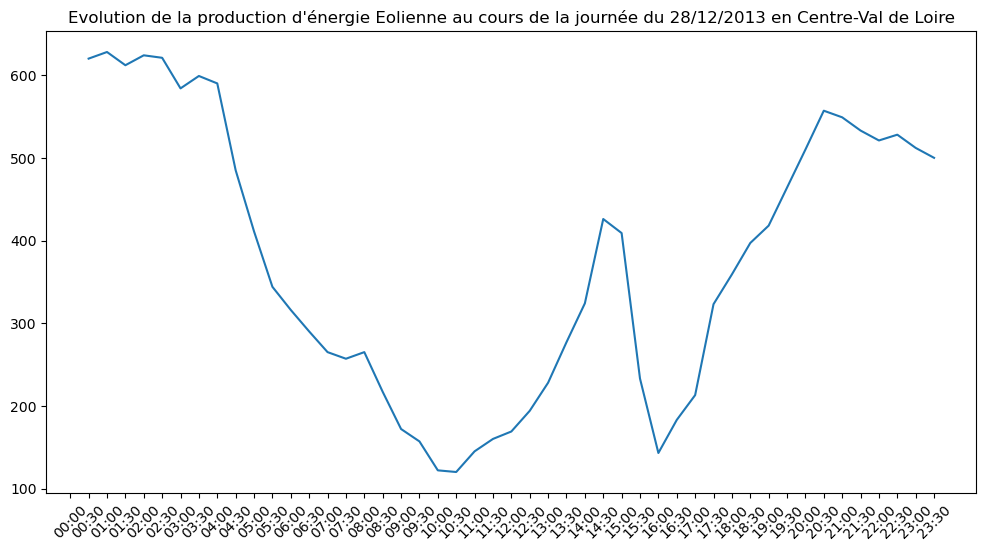

In [24]:
# Journée NAN du 27 décembre 2013 en Centre Val de Loire
# Filtrer pour la région Centre Val de Loire
idf = df[df["Région"] == "Centre-Val de Loire"]

# Les données du 9 mai 2013
idf = idf[(idf["Date"] == "2013-12-28")]

# Tracer la production éolienne
plt.figure(figsize=(12, 6))
plt.plot(idf["Heure"], idf["Eolien"], label = "Production éol")
plt.xticks(rotation = 45)
plt.title("Evolution de la production d'énergie Eolienne au cours de la journée du 28/12/2013 en Centre-Val de Loire")
plt.show()

# On fait pareil pour la journée manquante du Centre val de Loire en remplaçant par la journée suivante.

In [25]:
# Sélection des lignes à remplacer
cvl_27 = df[(df['Date'] == '2013-12-27') & (df['Heure'] != '00:00') & (df['Région'] == 'Centre-Val de Loire')]['Eolien']
cvl_28 = df[(df['Date'] == '2013-12-28') & (df['Région'] == 'Centre-Val de Loire')]['Eolien']

# Remplacement des valeurs
df.loc[(df['Date'] == '2013-12-27') & (df['Région'] == 'Centre-Val de Loire'), 'Eolien'] = cvl_28.values
# Il reste un NAN le 27/12/2013 à 00h00 et le 28/12/2013 à 00h00 du fait du décalage de fuseau horaire entre Europe/Paris et UTC. 
# On le remplace donc par le valeur de 00h30
df.loc[(df['Date'] == '2013-12-27') &(df['Région'] == 'Centre-Val de Loire') &(df['Heure'] == '00:00'), 'Eolien'] = 620.0
df.loc[(df['Date'] == '2013-12-28') &(df['Région'] == 'Centre-Val de Loire') &(df['Heure'] == '00:00'), 'Eolien'] = 500.0

df.loc[(df['Date'] == '2013-12-27') & (df['Région'] == 'Centre-Val de Loire')]

,Code région,Région,Date,Heure,Year,Date - Heure,Consommation,Thermique,Nucléaire,Eolien,...,TCO Nucléaire,TCH Nucléaire,TCO Eolien,TCH Eolien,TCO Solaire,TCH Solaire,TCO Hydraulique,TCH Hydraulique,TCO Bioénergies,TCH Bioénergies
207366,CVL,Centre-Val de Loire,2013-12-27,00:00,2013,2013-12-27 00:00:00+01:00,2649.0,78.0,9298.0,620.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207373,CVL,Centre-Val de Loire,2013-12-27,00:30,2013,2013-12-27 00:30:00+01:00,2597.0,78.0,9335.0,620.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207386,CVL,Centre-Val de Loire,2013-12-27,01:00,2013,2013-12-27 01:00:00+01:00,2481.0,78.0,9245.0,628.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207398,CVL,Centre-Val de Loire,2013-12-27,01:30,2013,2013-12-27 01:30:00+01:00,2601.0,78.0,9312.0,612.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207416,CVL,Centre-Val de Loire,2013-12-27,02:00,2013,2013-12-27 02:00:00+01:00,2546.0,78.0,9281.0,624.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207430,CVL,Centre-Val de Loire,2013-12-27,02:30,2013,2013-12-27 02:30:00+01:00,2498.0,78.0,9323.0,621.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207435,CVL,Centre-Val de Loire,2013-12-27,03:00,2013,2013-12-27 03:00:00+01:00,2400.0,78.0,8438.0,584.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207454,CVL,Centre-Val de Loire,2013-12-27,03:30,2013,2013-12-27 03:30:00+01:00,2257.0,77.0,8604.0,599.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207462,CVL,Centre-Val de Loire,2013-12-27,04:00,2013,2013-12-27 04:00:00+01:00,2305.0,74.0,8581.0,590.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207468,CVL,Centre-Val de Loire,2013-12-27,04:30,2013,2013-12-27 04:30:00+01:00,2243.0,74.0,8612.0,485.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


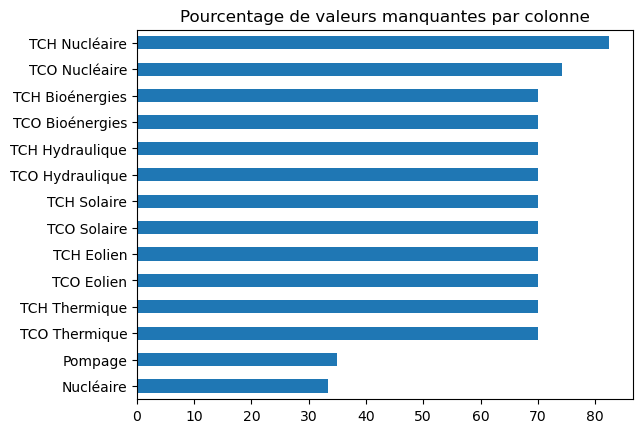

In [26]:
# Création d'un graphique pour illustrer le pourcentage de valeurs manquantes de df sur le reste des colonnes
nan_pourcent = df.isnull().mean() * 100
nan_pourcent[nan_pourcent > 0].sort_values().plot(kind='barh')
plt.title("Pourcentage de valeurs manquantes par colonne");

# Ce graphique contient toutes les colonnes qui ont des valeurs manquantes, soit 14 colonnes. 
# Il y a un haut taux de valeurs manquantes qui semble similaire pour les colonnes TCO et TCH. 
# Il est nécessaire d'explorer davantage ces colonnes.

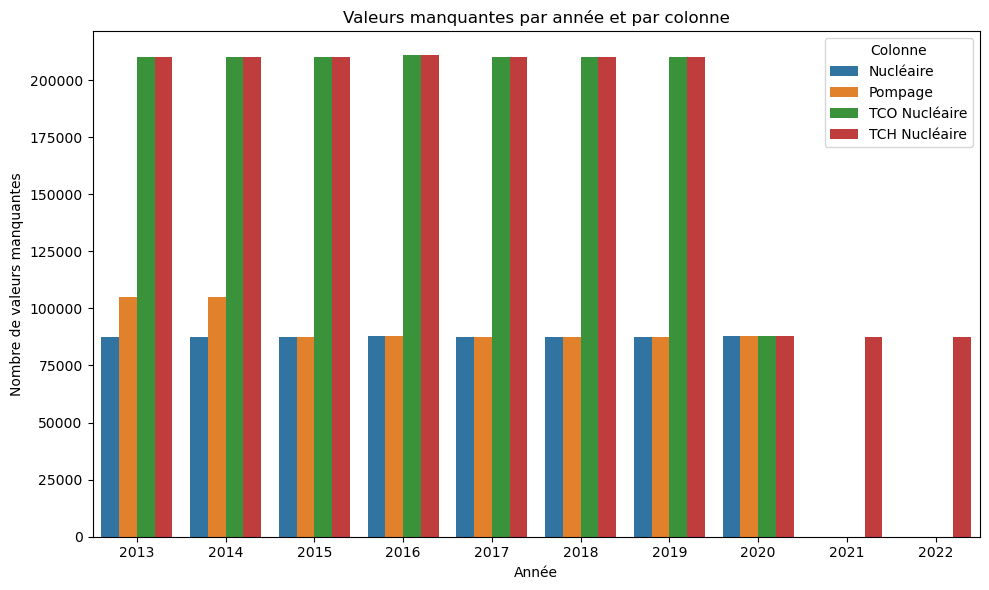

In [27]:
# Regardons plus en détails les 4 colonnes avec un taux de NAN différent des autres colonnes
# On repère les lignes avec des valeurs manquantes 
colonnes_cibles = ['Nucléaire', 'Pompage', 'TCO Nucléaire', 'TCH Nucléaire']

# Création d'un DataFrame de valeurs manquantes
df_missing_by_year = (df[df[colonnes_cibles].isnull().any(axis=1)].groupby('Year')[colonnes_cibles]
                      .apply(lambda x: x.isnull().sum()).reset_index()
                      .melt(id_vars='Year', var_name='Colonne', value_name='Nb manquants'))

# Tracé
plt.figure(figsize = (10, 6))
sns.barplot(data = df_missing_by_year, x = 'Year', y = 'Nb manquants', hue = 'Colonne')
plt.title("Valeurs manquantes par année et par colonne")
plt.ylabel("Nombre de valeurs manquantes")
plt.xlabel("Année")
plt.legend(title = "Colonne")
plt.tight_layout()
plt.show()

# Pour TCO Nucléaire et TCH Nucléaire, de 2013 à 2020, toutes les données sont manquantes chaque année.
# Ce n’est qu’en 2020 pour TCO que les valeurs commencent à apparaître partiellement et même là, leur absence reste très forte.
# En 2021, 2022 et 2023 TCH Nucléaire est la seule variable encore manquante (toutes les autres semblent complètes).
# En 2023, seules quelques valeurs de TCH Nucléaire sont manquantes, donc les données sont quasiment complètes.
# Les hypothèses possibles sont que les variables TCO et TCH ont peut-être été introduites dans le système de collecte de données très récemment.
# Ou bien il s'agit de données sensibles ou difficiles à mesurer, dont la collecte n’était pas systématique avant 2023.
# Certaines régions ne produisent pas d'énergie nucléaire, ni de pompage ce que nous analyserons par la suite.

In [28]:
# Pour les 14 colonnes, les mesures n'ont pas toutes démarrées en 2013 comme nous venons de le voir.
# Nous avons donc regardé par région la date de début d'enregistrement des données

# Exemple pour les NAN 'Nucléaire', 7 régions ont bien des enregistrements à partir du 2013-01-01 
# mais 5 seulement à partir de 2021-01-01

df_sansNA = df.sort_values('Date')
premiere_nucleaire_non_na = (df_sansNA.dropna(subset=['Nucléaire']).groupby('Région').first()['Date'])

print(premiere_nucleaire_non_na)

Région
Auvergne-Rhône-Alpes         2013-01-01
Bourgogne-Franche-Comté      2021-01-01
Bretagne                     2021-01-01
Centre-Val de Loire          2013-01-01
Grand Est                    2013-01-01
Hauts-de-France              2013-01-01
Normandie                    2013-01-01
Nouvelle-Aquitaine           2013-01-01
Occitanie                    2013-01-01
Pays de la Loire             2021-01-01
Provence-Alpes-Côte d'Azur   2021-01-01
Île-de-France                2021-01-01
Name: Date, dtype: datetime64[ns]


In [29]:
# Nous remplaçons les NAN 'Nucléaire' pour les 5 régions concernées avant 2021

nucleaire_before_2021 = (df['Région'].isin(["Bourgogne-Franche-Comté", "Bretagne", "Pays de la Loire", "Provence-Alpes-Côte d'Azur", "Île-de-France"])) & (df['Year'] < 2021) & (df['Nucléaire'].isna())
df_sansNA.loc[nucleaire_before_2021, 'Nucléaire'] = 0

In [30]:
# Nous avons répété cette opération pour les 14 colonnes afin de vérifier qu'il n'y avait pas de NAN 
# présents pour d'autres raisons. Le fichier ne comportant effectivement plus aucun NAN, nous avons décidé
# de ne pas appliquer la transformation de tous ces NAN. Les garder indique l'absence effective de mesures.

In [31]:
# On souhaite savoir si les NAN des colonnes TCO peuvent être remplacées par le calcul en regardant ce qu'il en est avec les données actuelles
# On crée un nouveau df sans nan en se basant sur la colonne Thermique pour les calculs
df_filtre = df.dropna(subset = ['Thermique', 'Consommation', 'TCO Thermique'])

# La formule du TCO
tco_attendu = (df_filtre['Thermique'] / df_filtre['Consommation']) * 100

# Comparaison avec la colonne TCO existante, arrondi à l'entier
egalite = np.isclose(df_filtre['TCO Thermique'], tco_attendu, rtol=1, atol=1)

# Conversion du np array en pd series pour utiliser la méthode value_counts()
egalite_series = pd.Series(egalite)

# Comptage des égalités et inégalités
comptage = egalite_series.value_counts()

# Résultat global
print("Nombre de valeurs correctes (True) :", comptage.get(True, 0))
print("Nombre de valeurs incorrectes (False) :", comptage.get(False, 0))

# On prend un échantillon de 20 lignes du df au hasard
display(df_filtre.sample(n = 20, random_state = 42))

# On se rend compte que tous les TCO observés correspondent bien aux attendus
# On a pu vérifier la cohérence des calculs pour l'ensemble des colonnes TCO

Nombre de valeurs correctes (True) : 631296
Nombre de valeurs incorrectes (False) : 0


,Code région,Région,Date,Heure,Year,Date - Heure,Consommation,Thermique,Nucléaire,Eolien,...,TCO Nucléaire,TCH Nucléaire,TCO Eolien,TCH Eolien,TCO Solaire,TCH Solaire,TCO Hydraulique,TCH Hydraulique,TCO Bioénergies,TCH Bioénergies
1962186,OCC,Occitanie,2022-04-30,13:30,2022,2022-04-30 13:30:00+02:00,3624.0,0.0,0.0,403.0,...,0.00,0.00,11.12,24.68,48.65,63.05,34.27,23.43,2.57,50.27
2005608,PAC,Provence-Alpes-Côte d'Azur,2022-07-14,23:00,2022,2022-07-14 23:00:00+02:00,4998.0,1074.0,0.0,2.0,...,0.00,NaN,0.04,2.06,0.00,0.00,25.29,38.62,1.56,25.66
1695031,ARA,Auvergne-Rhône-Alpes,2021-01-21,18:00,2021,2021-01-21 18:00:00+01:00,9340.0,279.0,10676.0,474.0,...,114.30,78.67,5.07,84.79,0.00,0.00,44.54,35.27,1.10,55.08
1885773,NOR,Normandie,2021-12-18,21:30,2021,2021-12-18 21:30:00+01:00,3807.0,385.0,6319.0,220.0,...,165.98,59.39,5.78,24.28,0.00,0.00,0.34,43.33,2.31,59.46
1739960,PAC,Provence-Alpes-Côte d'Azur,2021-04-09,18:00,2021,2021-04-09 18:00:00+02:00,4387.0,1208.0,0.0,34.0,...,0.00,NaN,0.78,35.05,7.70,23.54,10.74,14.39,1.46,21.19
1880728,BRE,Bretagne,2021-12-10,03:30,2021,2021-12-10 03:30:00+01:00,2857.0,434.0,0.0,756.0,...,0.00,NaN,26.46,67.74,0.00,0.00,5.15,53.45,1.75,61.73
1957043,HDF,Hauts-de-France,2022-04-21,15:00,2022,2022-04-21 15:00:00+02:00,5231.0,620.0,3439.0,1576.0,...,65.74,62.99,30.13,28.90,5.22,73.19,0.06,75.00,2.05,54.31
2098332,PAC,Provence-Alpes-Côte d'Azur,2022-12-22,22:30,2022,2022-12-22 22:30:00+01:00,4608.0,656.0,0.0,34.0,...,0.00,NaN,0.74,35.42,0.00,0.00,17.10,24.14,4.73,73.40
1818351,ARA,Auvergne-Rhône-Alpes,2021-08-23,20:30,2021,2021-08-23 20:30:00+02:00,6194.0,5.0,9048.0,289.0,...,146.08,66.68,4.67,42.13,0.08,0.38,68.24,35.82,1.79,59.04
1876506,PDL,Pays de la Loire,2021-12-02,19:30,2021,2021-12-02 19:30:00+01:00,4931.0,1274.0,0.0,306.0,...,0.00,NaN,6.21,26.47,0.00,0.00,0.08,36.36,1.18,72.50


In [32]:
# Illustration par l'affichage 
df_thermique = df[['Thermique', 'Consommation', 'TCO Thermique']]
df_thermique = df_thermique.dropna()

df_thermique['TCO Thermique attendu'] = (df_thermique['Thermique'] / df_thermique['Consommation']) * 100

df_thermique.head(10)

# On peut donc remplacer les valeurs NAN de la colonne TCO Thermique par le calcul

,Thermique,Consommation,TCO Thermique,TCO Thermique attendu
1472256,105.0,2965.0,3.54,3.541315
1472257,181.0,2737.0,6.61,6.613080
1472258,359.0,4078.0,8.80,8.803335
1472259,326.0,10462.0,3.12,3.116039
1472260,2030.0,6582.0,30.84,30.841689
1472261,94.0,5591.0,1.68,1.681273
1472262,1258.0,6123.0,20.55,20.545484
1472263,1503.0,5703.0,26.35,26.354550
1472264,240.0,3595.0,6.68,6.675939
1472265,350.0,4275.0,8.19,8.187135


In [33]:
# Remplacement des NAN des colonnes TCO 
df['TCO Thermique'] = df['TCO Thermique'].fillna((df['Thermique'] / df['Consommation']) * 100)
df['TCO Solaire'] = df['TCO Solaire'].fillna((df['Solaire'] / df['Consommation']) * 100)
df['TCO Eolien'] = df['TCO Eolien'].fillna((df['Eolien'] / df['Consommation']) * 100)
df['TCO Nucléaire'] = df['TCO Nucléaire'].fillna((df['Nucléaire'] / df['Consommation']) * 100)
df['TCO Bioénergies'] = df['TCO Bioénergies'].fillna((df['Bioénergies'] / df['Consommation']) * 100)
df['TCO Hydraulique'] = df['TCO Hydraulique'].fillna((df['Hydraulique'] / df['Consommation']) * 100)

# Malheureusement, nous n'avons pas les données sur la 'capacité installée' par région et par filière de production, 
# ce qui nous empêche de calculer les TCH manquants

In [34]:
# Vérification de la prise en compte des calculs
df.isna().sum()

Code région              0
Région                   0
Date                     0
Heure                    0
Year                     0
Date - Heure             0
Consommation             0
Thermique                0
Nucléaire           701275
Eolien                   0
Solaire                  0
Hydraulique              0
Pompage             736315
Bioénergies              0
Ech. physiques           0
TCO Thermique            0
TCH Thermique      1472244
TCO Nucléaire       701275
TCH Nucléaire      1735284
TCO Eolien               0
TCH Eolien         1472244
TCO Solaire              0
TCH Solaire        1472244
TCO Hydraulique          0
TCH Hydraulique    1472244
TCO Bioénergies          0
TCH Bioénergies    1472244
dtype: int64

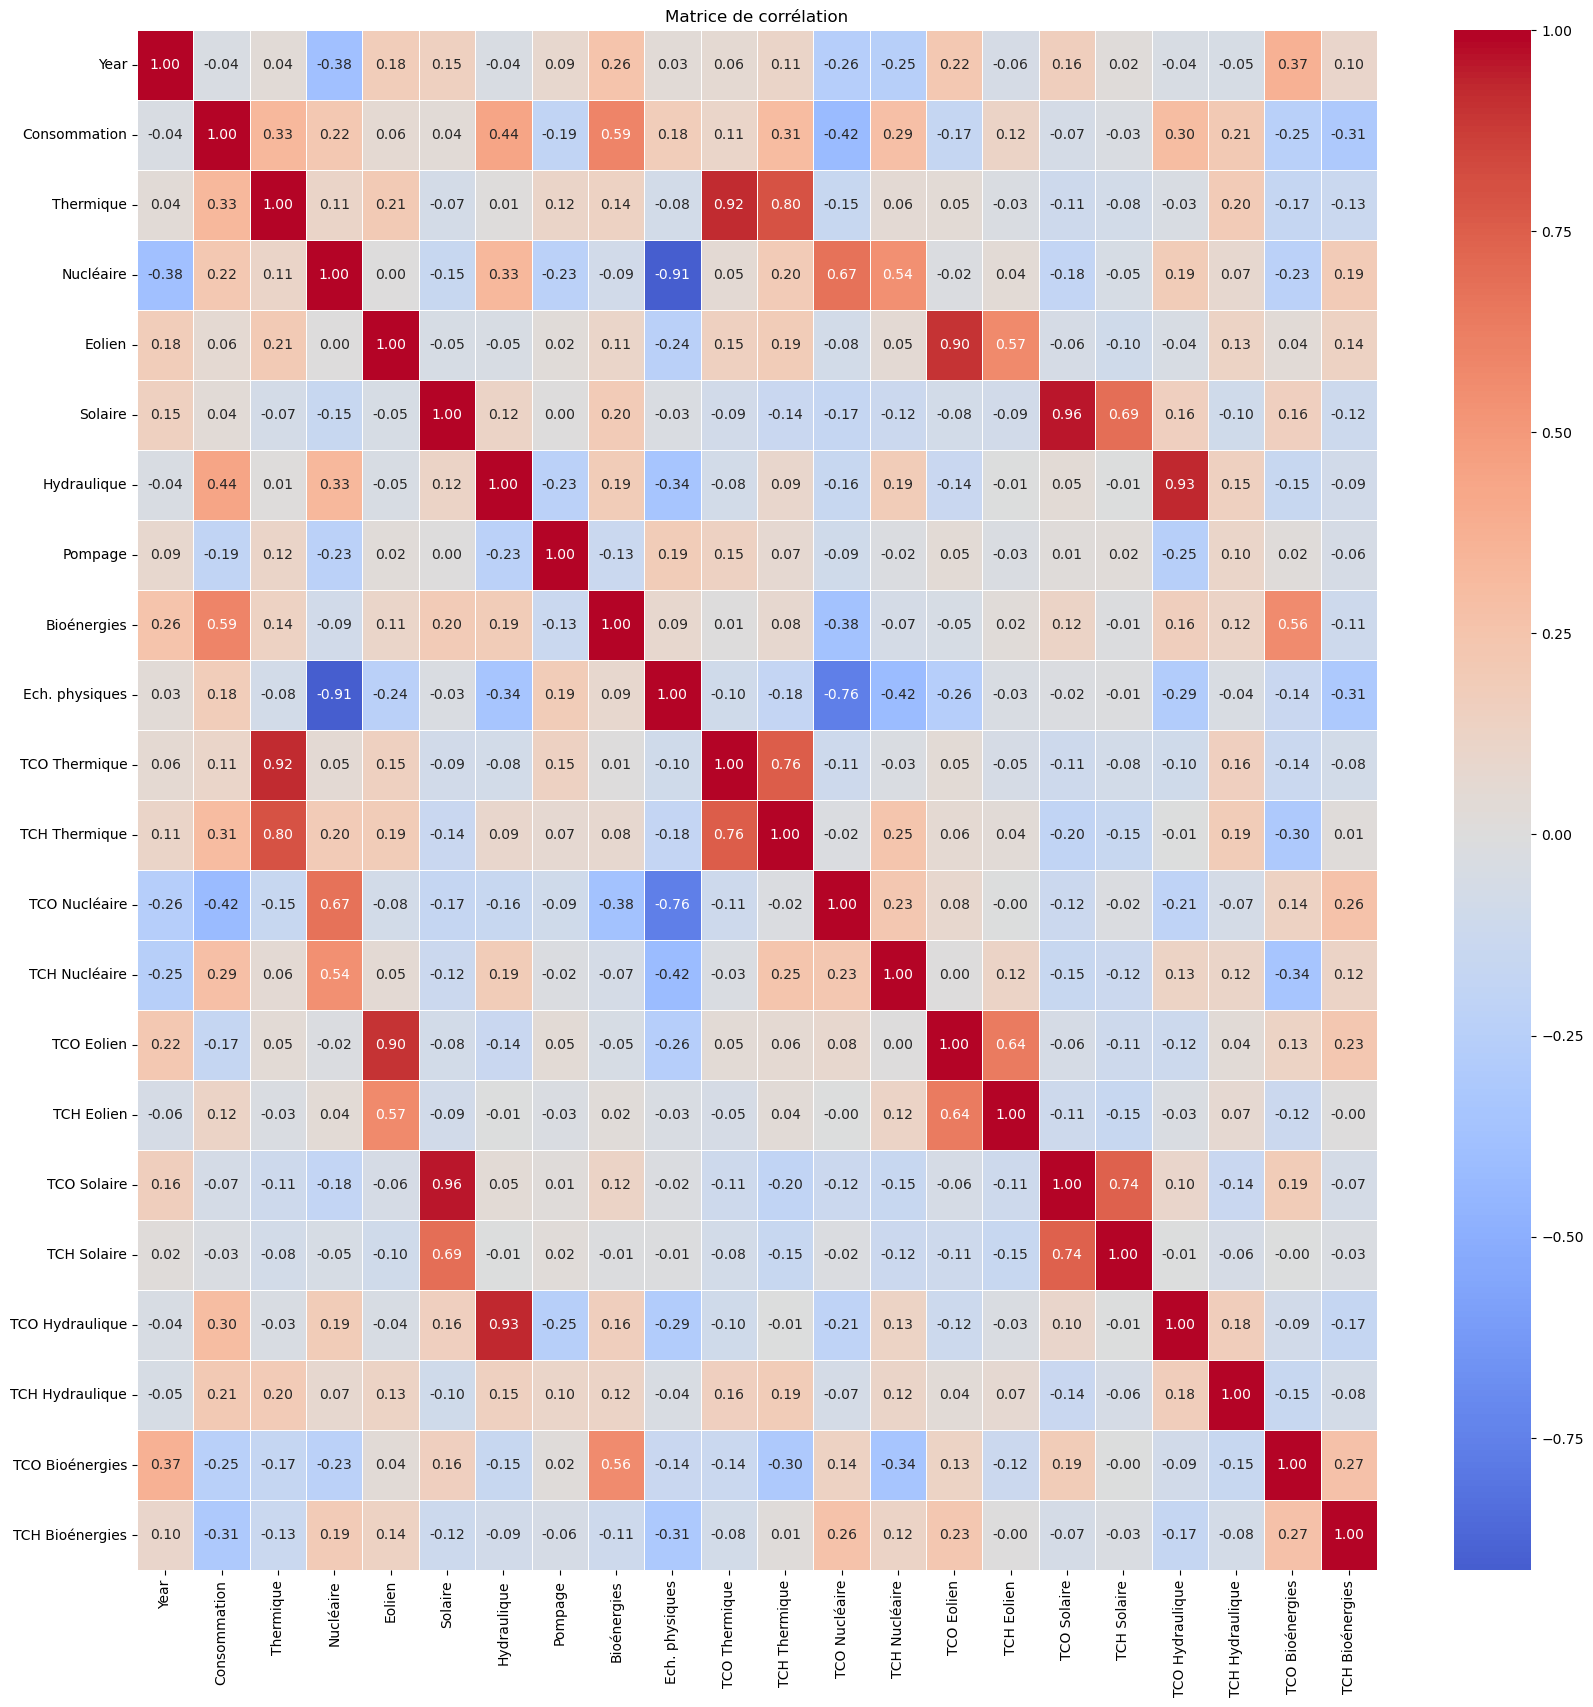

In [35]:
# Il serait intéressant de connaître la corrélation entre les variables
# Calculer la matrice de corrélation
corr_matrix = df.corr(numeric_only=True)

# Tracer la heatmap
plt.figure(figsize = (20, 20))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f", center = 0, linewidths = 0.5)
plt.title("Matrice de corrélation")
plt.show()

# Comme attendu, les corrélations fortes (+0.7) apparaissent entre la production d'un type d'énergie et son TCO 
# et TCH. Par exemple : Thermique avec TCO Thermique (+0.92) et TCH Thermique (+0.80)
# On a aussi une corrélation forte négative entre Échanges physiques avec TCO Nucléaire (-0.78) et Nucléaire (-0.91).
# On peut supposer que plus la production nucléaire est élevée, moins les échanges physiques sont importants 
# (et probablement à l’importation).
# A l’inverse, quand le nucléaire produit peu, la France semble compenser par des échanges transfrontaliers (importations).
# Il existe aussi quelques corrélation modérées comme Consommation qui en a avec Thermique (+0.33), Hydraulique (+0.44)
# et Bioénergies (+0.59).
# Cela peut s'expliquer par le fait que ces 3 énergies sont celles le plus sollicitées pour répondre à la demande qui augmente.
# Et Année est modérément corrélée avec certaines variables (jusqu’à 0.26 avec Bioénergies), ce qui pourrait indiquer 
# des tendances temporelles lentes.

In [36]:
# Puis avec les variables catégorielles
var_categorielles = df.select_dtypes(include='object').columns

# Nombre de modalités par variable catégorielle
for col in df.select_dtypes(include=['object', 'category']).columns:
    nb = df[col].nunique()
    print(f"{col} : {nb} catégorie(s) unique(s)")

# Afficher les valeurs uniques et leur fréquence pour chaque colonne catégorielle
for col in var_categorielles:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False)) 

print(var_categorielles.unique())

# Comme attendu, on a bien 12 Code région correspondant au 12 régions et 48 heures (24 x 2, pour les mesures toutes
# les demi-heures).

Code région : 12 catégorie(s) unique(s)
Région : 12 catégorie(s) unique(s)
Heure : 48 catégorie(s) unique(s)
Date - Heure : 175275 catégorie(s) unique(s)

--- Code région ---
Code région
GES    175295
IDF    175295
PDL    175295
CVL    175295
BFC    175295
OCC    175295
PAC    175295
NOR    175295
HDF    175295
NAQ    175295
ARA    175295
BRE    175295
Name: count, dtype: int64

--- Région ---
Région
Grand Est                     175295
Île-de-France                 175295
Pays de la Loire              175295
Centre-Val de Loire           175295
Bourgogne-Franche-Comté       175295
Occitanie                     175295
Provence-Alpes-Côte d'Azur    175295
Normandie                     175295
Hauts-de-France               175295
Nouvelle-Aquitaine            175295
Auvergne-Rhône-Alpes          175295
Bretagne                      175295
Name: count, dtype: int64

--- Heure ---
Heure
00:30    43824
01:00    43824
13:30    43824
14:00    43824
14:30    43824
15:00    43824
15:30    43824


In [37]:
# On veut explorer les variables et leur distribution 
# On commence avec les variables numériques 
var_numeriques = df.select_dtypes(include = 'number').describe().T # pour transposer les lignes en colonnes
display(var_numeriques)

,count,mean,std,min,25%,50%,75%,max
Year,2103540.0,2017.500299,2.871889,2013.000000,2015.000000,2018.000000,2020.000000,2022.000000
Consommation,2103540.0,4466.998477,2159.696297,703.000000,2762.000000,4096.000000,5700.000000,15338.000000
Thermique,2103540.0,380.784838,539.924051,-83.000000,25.000000,159.000000,499.000000,4293.000000
Nucléaire,1402265.0,5340.977959,3496.459354,-144.000000,2555.000000,5238.000000,8187.000000,13632.000000
Eolien,2103540.0,262.568762,443.935017,-6.000000,28.000000,108.000000,306.000000,4971.000000
Solaire,2103540.0,97.195359,238.883935,-23.000000,0.000000,1.000000,70.000000,2882.000000
Hydraulique,2103540.0,588.515093,1012.803042,-6.000000,5.000000,55.000000,860.000000,8468.000000
Pompage,1367225.0,-101.634052,295.136240,-2580.000000,-7.000000,0.000000,0.000000,0.000000
Bioénergies,2103540.0,84.830527,45.220937,4.000000,49.000000,76.000000,117.000000,2300.000000
Ech. physiques,2103540.0,-441.422603,4292.299058,-12219.000000,-4052.000000,571.000000,2211.000000,13959.000000


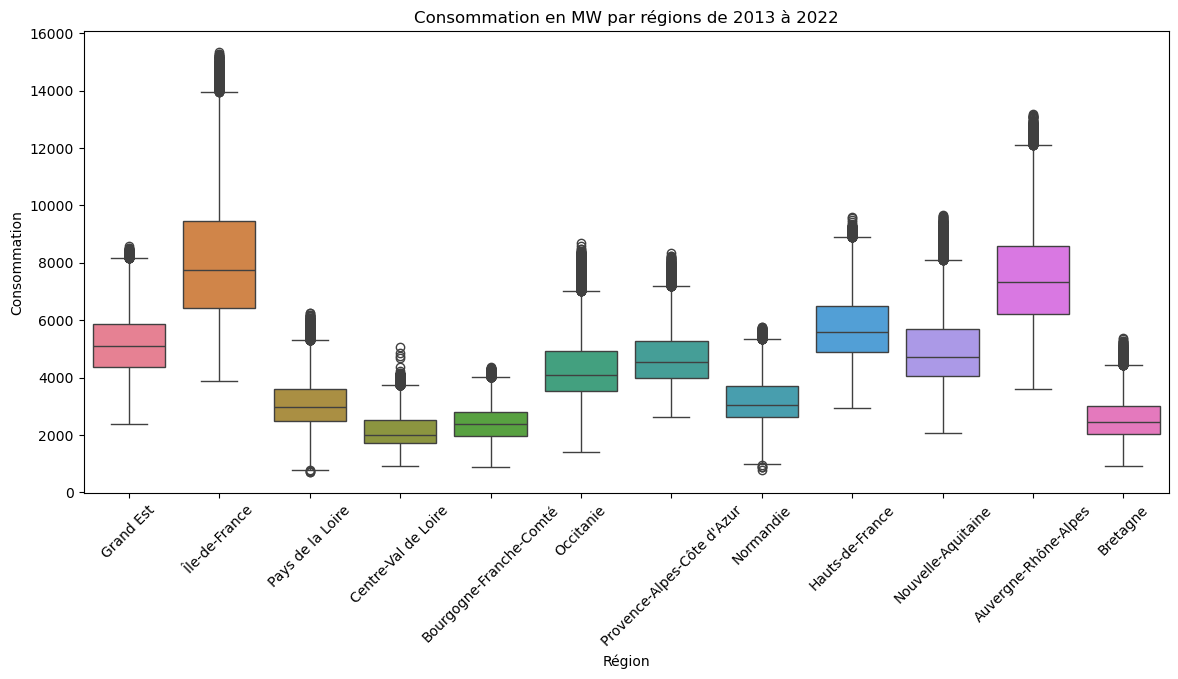

In [38]:
# Regardons ce qu'il en est avec des boxplots
# Débutons par la valeur Consommation
plt.figure(figsize = (14, 6))
sns.boxplot(data = df, x = 'Région', y = 'Consommation', hue = 'Région')
plt.xticks(rotation = 45)
plt.title('Consommation en MW par régions de 2013 à 2022')
plt.show()
# Nous remarquons que 2 régions consomment plus que les autres (IDF et ARA), probablement en raison des densités
# de population plus élevées. Nous remarquons que pour chacune des régions il y a des valeurs extrèmes maximales
# qu'il sera intéressant d'étudier

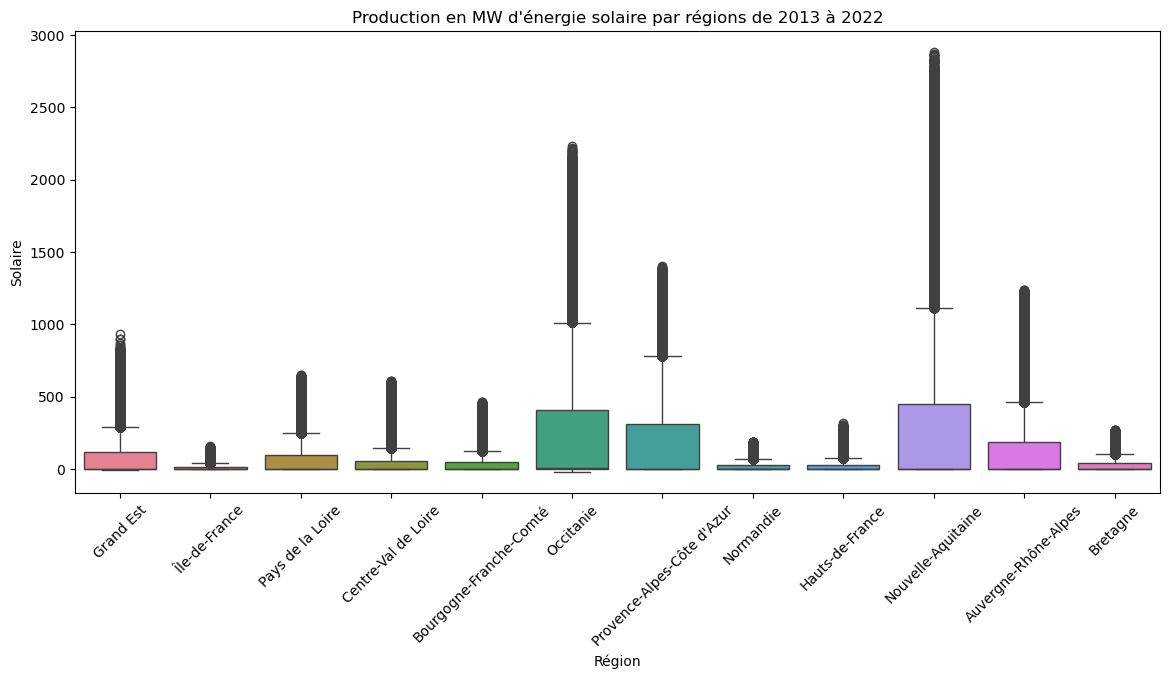

In [39]:
# Passons à l'énergie solaire
plt.figure(figsize = (14, 6))
sns.boxplot(data = df, x = 'Région', y = 'Solaire', hue = 'Région')
plt.xticks(rotation = 45)
plt.title('Production en MW d\'énergie solaire par régions de 2013 à 2022')
plt.show()
# Une nouvelle fois nous n'observons pas de valeurs aberrantes mais des valeurs extrêmes positives.
# Les régions les plus ensoleillées (OCC, PAC, NAQ) ont l'air de favoriser ce type de production.
# On observe des spécifités par région pour chacune des énergies, ce que nous étudirons par la suite.

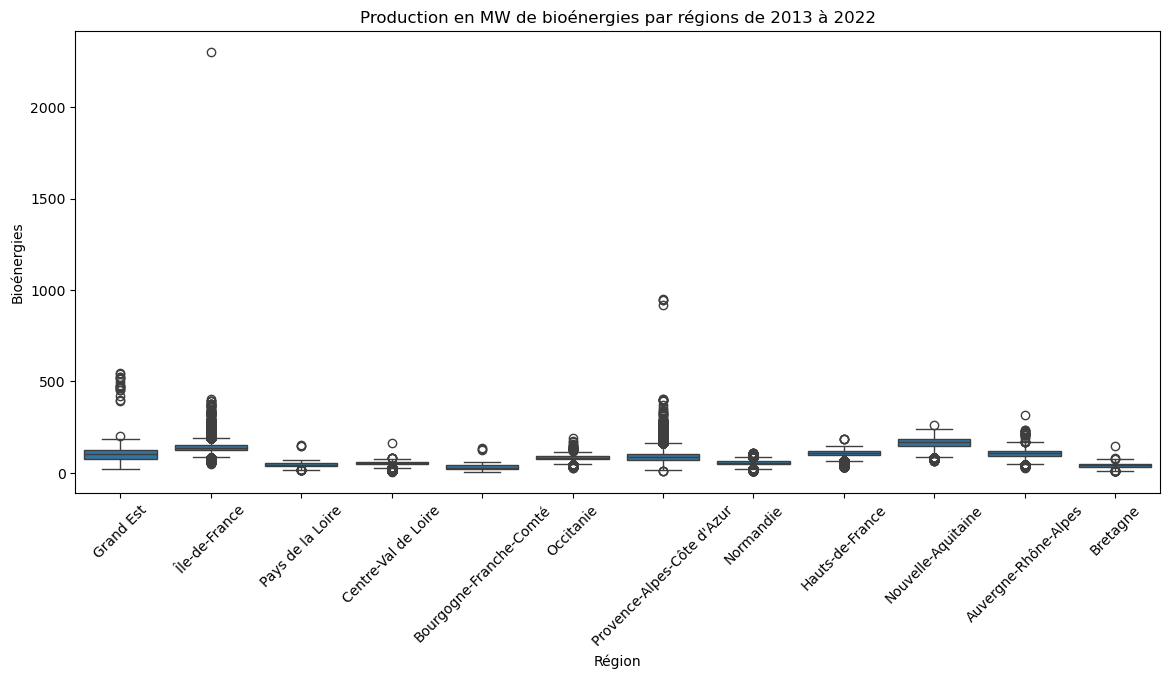

In [40]:
# Les bioénergies 
plt.figure(figsize = (14, 6))
sns.boxplot(data = df, x = 'Région', y = 'Bioénergies')
plt.xticks(rotation = 45)
plt.title('Production en MW de bioénergies par régions de 2013 à 2022')
plt.show()
# Cette fois-ci, nous observons des valeurs aberrantes pour 3 régions (IDF, GES, PAC)
# Nous notons également que cette source d'énergie est utilisé dans une moindre mesure

In [41]:
idf = df[df['Région'] == 'Île-de-France']
idf_top5_bio = idf.nlargest(5, 'Bioénergies')
pd.set_option("display.max_columns", None)
display(idf_top5_bio)
# Pour l'Île de France on observe une valeur aberrante unique, 5 fois plus élevée que les valeurs max de cette 
# variable. Pas assez d'information pour en faire quoique ce soit => on ne touche à rien

,Code région,Région,Date,Heure,Year,Date - Heure,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,Bioénergies,Ech. physiques,TCO Thermique,TCH Thermique,TCO Nucléaire,TCH Nucléaire,TCO Eolien,TCH Eolien,TCO Solaire,TCH Solaire,TCO Hydraulique,TCH Hydraulique,TCO Bioénergies,TCH Bioénergies
1731261,IDF,Île-de-France,2021-03-25,15:30,2021,2021-03-25 15:30:00+01:00,10791.0,386.0,0.0,15.0,43.0,9.0,0.0,2300.0,8039.0,3.58,17.37,0.0,NaN,0.14,14.15,0.40,28.48,0.08,45.0,21.31,718.75
1854556,IDF,Île-de-France,2021-10-25,17:00,2021,2021-10-25 17:00:00+02:00,8702.0,0.0,0.0,18.0,19.0,7.0,0.0,405.0,8253.0,0.00,0.00,0.0,NaN,0.21,14.17,0.22,10.33,0.08,35.0,4.65,124.62
1854546,IDF,Île-de-France,2021-10-25,16:30,2021,2021-10-25 16:30:00+02:00,8698.0,3.0,0.0,22.0,21.0,7.0,0.0,395.0,8250.0,0.03,0.14,0.0,NaN,0.25,17.32,0.24,11.41,0.08,35.0,4.54,121.54
1854591,IDF,Île-de-France,2021-10-25,18:30,2021,2021-10-25 18:30:00+02:00,8962.0,0.0,0.0,32.0,2.0,8.0,0.0,395.0,8524.0,0.00,0.00,0.0,NaN,0.36,25.20,0.02,1.09,0.09,40.0,4.41,121.54
1854762,IDF,Île-de-France,2021-10-26,01:30,2021,2021-10-26 01:30:00+02:00,7010.0,0.0,0.0,39.0,0.0,9.0,0.0,393.0,6571.0,0.00,0.00,0.0,NaN,0.56,30.71,0.00,0.00,0.13,45.0,5.61,120.92


In [42]:
ges = df[df['Région'] == 'Grand Est']
ges_top5_bio = ges.nlargest(10, 'Bioénergies')
pd.set_option("display.max_columns", None)
display(ges_top5_bio)
# Les valeurs max dans le Grand Est ont l'air d'avoir toutes été mesurées le même jour mais sont de même ordre
# que les valeurs qui suivent => on ne touche à rien

,Code région,Région,Date,Heure,Year,Date - Heure,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,Bioénergies,Ech. physiques,TCO Thermique,TCH Thermique,TCO Nucléaire,TCH Nucléaire,TCO Eolien,TCH Eolien,TCO Solaire,TCH Solaire,TCO Hydraulique,TCH Hydraulique,TCO Bioénergies,TCH Bioénergies
1633875,GES,Grand Est,2020-10-07,14:00,2020,2020-10-07 14:00:00+02:00,5994.0,867.0,9116.0,1546.0,182.0,935.0,0.0,548.0,-7201.0,14.46,27.37,152.09,84.25,25.79,42.61,3.04,32.79,15.60,40.51,9.14,243.56
1633855,GES,Grand Est,2020-10-07,13:00,2020,2020-10-07 13:00:00+02:00,6241.0,1129.0,9104.0,1703.0,188.0,935.0,0.0,542.0,-7360.0,18.09,35.64,145.87,84.14,27.29,46.94,3.01,33.87,14.98,40.51,8.68,240.89
1633836,GES,Grand Est,2020-10-07,12:30,2020,2020-10-07 12:30:00+02:00,6135.0,1187.0,9171.0,1727.0,170.0,932.0,0.0,526.0,-7579.0,19.35,37.47,149.49,84.76,28.15,47.60,2.77,30.63,15.19,40.38,8.57,233.78
1633865,GES,Grand Est,2020-10-07,13:30,2020,2020-10-07 13:30:00+02:00,6013.0,1068.0,9119.0,1685.0,191.0,935.0,0.0,524.0,-7509.0,17.76,33.71,151.65,84.28,28.02,46.44,3.18,34.41,15.55,40.51,8.71,232.89
1634069,GES,Grand Est,2020-10-07,22:00,2020,2020-10-07 22:00:00+02:00,5348.0,798.0,9011.0,1269.0,0.0,936.0,0.0,518.0,-7183.0,14.92,25.19,168.49,83.28,23.73,34.98,0.00,0.00,17.50,40.55,9.69,230.22
1633897,GES,Grand Est,2020-10-07,15:00,2020,2020-10-07 15:00:00+02:00,5904.0,867.0,9145.0,1655.0,216.0,938.0,0.0,515.0,-7432.0,14.68,27.37,154.89,84.52,28.03,45.62,3.66,38.92,15.89,40.64,8.72,228.89
1634505,GES,Grand Est,2020-10-08,16:00,2020,2020-10-08 16:00:00+02:00,5814.0,586.0,8964.0,2450.0,102.0,939.0,0.0,496.0,-7723.0,10.08,18.50,154.18,82.85,42.14,67.53,1.75,18.38,16.15,40.68,8.53,220.44
1645929,GES,Grand Est,2020-10-28,12:00,2020,2020-10-28 12:00:00+01:00,6468.0,1179.0,9658.0,2389.0,224.0,1011.0,0.0,479.0,-8473.0,18.23,37.22,149.32,89.26,36.94,65.85,3.46,40.36,15.63,43.80,7.41,212.89
1645914,GES,Grand Est,2020-10-28,11:30,2020,2020-10-28 11:30:00+01:00,6274.0,1142.0,9719.0,2262.0,201.0,1012.0,0.0,476.0,-8538.0,18.20,36.05,154.91,89.82,36.05,62.35,3.20,36.22,16.13,43.85,7.59,211.56
1634181,GES,Grand Est,2020-10-08,02:30,2020,2020-10-08 02:30:00+02:00,4921.0,104.0,8452.0,1162.0,0.0,938.0,0.0,473.0,-6209.0,2.11,3.28,171.75,78.11,23.61,32.03,0.00,0.00,19.06,40.64,9.61,210.22


In [43]:
pac = df[df['Région'] == 'Provence-Alpes-Côte d\'Azur']
pac_top5_bio = pac.nlargest(5, 'Bioénergies')
pd.set_option("display.max_columns", None)
display(pac_top5_bio)
# On observe 4 valeurs 2 fois plus élevées que les suivantes toutes mesurées le même jour, mais diffile d'en tirer
# quelque chose. => on ne touche à rien

,Code région,Région,Date,Heure,Year,Date - Heure,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,Bioénergies,Ech. physiques,TCO Thermique,TCH Thermique,TCO Nucléaire,TCH Nucléaire,TCO Eolien,TCH Eolien,TCO Solaire,TCH Solaire,TCO Hydraulique,TCH Hydraulique,TCO Bioénergies,TCH Bioénergies
1744412,PAC,Provence-Alpes-Côte d'Azur,2021-04-17,11:30,2021,2021-04-17 11:30:00+02:00,6222.0,708.0,0.0,9.0,557.0,711.0,-51.0,953.0,3334.0,11.380000,21.37,0.0,NaN,0.14000,9.28,8.950000,38.79,11.430000,21.72,15.320000,315.56
1744438,PAC,Provence-Alpes-Côte d'Azur,2021-04-17,12:30,2021,2021-04-17 12:30:00+02:00,6431.0,767.0,0.0,8.0,692.0,617.0,-51.0,947.0,3452.0,11.930000,23.15,0.0,NaN,0.12000,8.25,10.760000,48.19,9.590000,18.85,14.730000,313.58
1744427,PAC,Provence-Alpes-Côte d'Azur,2021-04-17,12:00,2021,2021-04-17 12:00:00+02:00,6325.0,768.0,0.0,9.0,652.0,646.0,-51.0,945.0,3356.0,12.140000,23.18,0.0,NaN,0.14000,9.28,10.310000,45.40,10.210000,19.74,14.940000,312.91
1744393,PAC,Provence-Alpes-Côte d'Azur,2021-04-17,11:00,2021,2021-04-17 11:00:00+02:00,6124.0,699.0,0.0,7.0,443.0,742.0,0.0,916.0,3317.0,11.410000,21.10,0.0,NaN,0.11000,7.22,7.230000,30.85,12.120000,22.67,14.960000,303.31
928887,PAC,Provence-Alpes-Côte d'Azur,2017-06-01,15:30,2017,2017-06-01 15:30:00+02:00,4607.0,97.0,NaN,5.0,429.0,1504.0,0.0,404.0,2168.0,2.105492,NaN,NaN,NaN,0.10853,NaN,9.311917,NaN,32.645974,NaN,8.769264,NaN


In [44]:
# De la même manière, nous observons des valeurs aberrantes :
# - pour les mêmes régions (IDF, GES et PAC) pour les variables TCH et TCO Bioénergies (variables corrélées comme 
# nous l'avons vu plus haut)
# - pour les régions NOR et HDF pour la variable TCH Hydraulique
# Le peu de données concernées, nous laisse penser qu'il n'est pas la peine de les traiter.

In [45]:
# Nous partons donc sur un fichier contenant 2 103 540 lignes et 27 colonnes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2103540 entries, 12 to 2103551
Data columns (total 27 columns):
 #   Column           Dtype         
---  ------           -----         
 0   Code région      object        
 1   Région           object        
 2   Date             datetime64[ns]
 3   Heure            object        
 4   Year             int32         
 5   Date - Heure     object        
 6   Consommation     float64       
 7   Thermique        float64       
 8   Nucléaire        float64       
 9   Eolien           float64       
 10  Solaire          float64       
 11  Hydraulique      float64       
 12  Pompage          float64       
 13  Bioénergies      float64       
 14  Ech. physiques   float64       
 15  TCO Thermique    float64       
 16  TCH Thermique    float64       
 17  TCO Nucléaire    float64       
 18  TCH Nucléaire    float64       
 19  TCO Eolien       float64       
 20  TCH Eolien       float64       
 21  TCO Solaire      float64       
 22

In [46]:
# sauvegarde de ce fichier nettoyé
df.to_csv('nrj_nettoye_v1.csv')